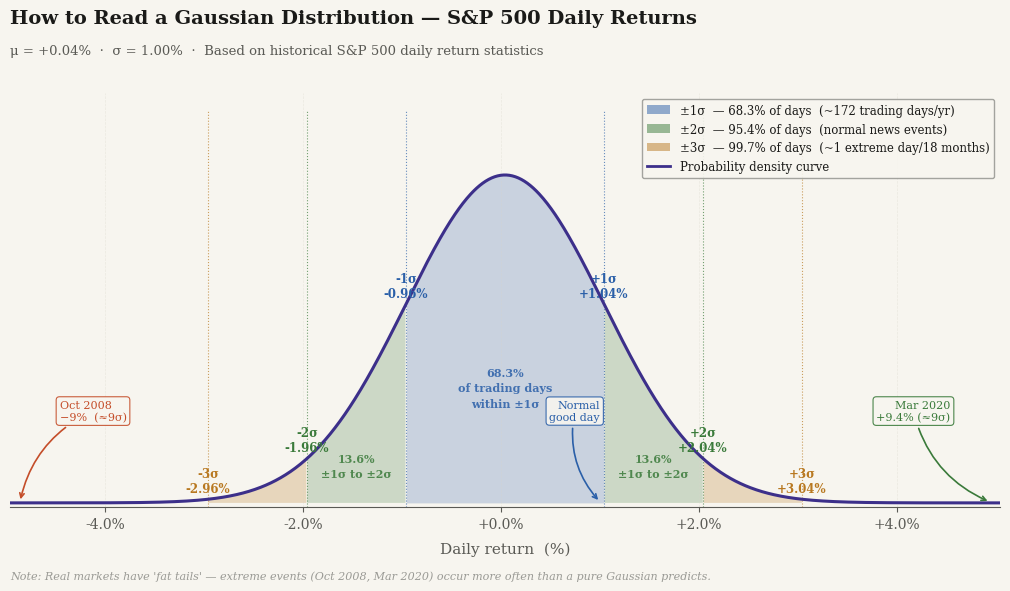

Saved: gaussian_sp500.png  +  gaussian_sp500.svg


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Parameters (S&P 500 historical daily return stats) ──────────────────────
MEAN  = 0.04   # % mean daily return
SD    = 1.00   # % daily standard deviation
X_LIM = 5      # show ±5σ on x-axis

# ── Derived values ───────────────────────────────────────────────────────────
x = np.linspace(MEAN - X_LIM * SD, MEAN + X_LIM * SD, 1000)

def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

y = gaussian(x, MEAN, SD)

# Sigma band masks
z = (x - MEAN) / SD
mask1 = np.abs(z) <= 1          # ±1σ  → 68.3%
mask2 = (np.abs(z) > 1) & (np.abs(z) <= 2)   # 1–2σ → 27.1%  (together = 95.4%)
mask3 = (np.abs(z) > 2) & (np.abs(z) <= 3)   # 2–3σ → 4.3%   (together = 99.7%)

# ── Style ────────────────────────────────────────────────────────────────────
PAPER   = "#f7f5ef"
INK     = "#1a1a18"
INK2    = "#5a5a55"
INK3    = "#9a9a95"
BLUE    = "#2a5fa8"
GREEN   = "#3a7a3a"
AMBER   = "#b87820"
RED     = "#c44d29"
CURVE   = "#3c2f8a"

plt.rcParams.update({
    "font.family": "serif",
    "axes.facecolor": PAPER,
    "figure.facecolor": PAPER,
    "axes.edgecolor": INK2,
    "axes.labelcolor": INK2,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "grid.color": "#d8d5ca",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "text.color": INK,
})

fig, ax = plt.subplots(figsize=(11, 6))
fig.subplots_adjust(left=0.07, right=0.97, top=0.82, bottom=0.13)

# ── Filled sigma bands ───────────────────────────────────────────────────────
for mask, color, alpha_lo, alpha_hi in [
    (mask1, BLUE,  0.18, 0.40),
    (mask2, GREEN, 0.18, 0.40),
    (mask3, AMBER, 0.20, 0.45),
]:
    ax.fill_between(x, y, where=mask, color=color, alpha=alpha_lo, linewidth=0)
    # slightly stronger border on the fill
    ax.fill_between(x, y, where=mask, color=color, alpha=0.05, linewidth=0)

# ── Bell curve ───────────────────────────────────────────────────────────────
ax.plot(x, y, color=CURVE, linewidth=2.2, zorder=5)

# ── Sigma boundary lines ─────────────────────────────────────────────────────
for s, color in [(-3, AMBER), (-2, GREEN), (-1, BLUE),
                 ( 1, BLUE),  ( 2, GREEN), ( 3, AMBER)]:
    xv = MEAN + s * SD
    yv = gaussian(xv, MEAN, SD)
    ax.axvline(xv, ymin=0, ymax=0.96, color=color, linewidth=0.8,
               linestyle=":", alpha=0.7, zorder=3)
    sign = "+" if s > 0 else ""
    ax.text(xv, yv + 0.005, f"{sign}{s}σ\n{xv:+.2f}%",
            ha="center", va="bottom", fontsize=8.5,
            color=color, fontweight="bold", zorder=6)

# ── Real event markers ───────────────────────────────────────────────────────
events = [
    (-9.0,  "Oct 2008\n−9%  (≈9σ)", "left",  RED),
    ( 9.4,  "Mar 2020\n+9.4% (≈9σ)", "right", GREEN),
    ( 1.0,  "Normal\ngood day", "right", BLUE),
]
for xv, label, ha, color in events:
    ax.annotate(
        label,
        xy=(min(max(xv, x[0]+0.1), x[-1]-0.1), 0.001),
        xytext=(min(max(xv, x[0]+0.5), x[-1]-0.5),
                gaussian(MEAN, MEAN, SD) * 0.28),
        arrowprops=dict(arrowstyle="->", color=color,
                        lw=1.2, connectionstyle="arc3,rad=0.25"),
        fontsize=8, color=color, ha=ha, va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc=PAPER, ec=color,
                  lw=0.8, alpha=0.9),
        zorder=7,
    )

# ── Probability annotations inside fills ─────────────────────────────────────
band_labels = [
    (MEAN, 0.14,  "68.3%\nof trading days\nwithin ±1σ",  BLUE),
    (MEAN + 1.5 * SD, 0.045, "13.6%\n±1σ to ±2σ",       GREEN),
    (MEAN - 1.5 * SD, 0.045, "13.6%\n±1σ to ±2σ",       GREEN),
]
for bx, by, txt, color in band_labels:
    ax.text(bx, by, txt, ha="center", va="center",
            fontsize=8, color=color, alpha=0.85,
            fontweight="bold", linespacing=1.5)

# ── Axes & labels ────────────────────────────────────────────────────────────
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-0.005, gaussian(MEAN, MEAN, SD) * 1.25)
ax.set_xlabel("Daily return  (%)", fontsize=11, labelpad=8)
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.1f}%"))
ax.grid(axis="x", alpha=0.4)
ax.spines[["top", "right", "left"]].set_visible(False)

# ── Title block ──────────────────────────────────────────────────────────────
fig.text(0.07, 0.93,
         "How to Read a Gaussian Distribution — S&P 500 Daily Returns",
         fontsize=14, fontweight="bold", color=INK, va="bottom")
fig.text(0.07, 0.88,
         f"μ = {MEAN:+.2f}%  ·  σ = {SD:.2f}%  ·  Based on historical S&P 500 daily return statistics",
         fontsize=9.5, color=INK2, va="bottom")

# ── Legend ───────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=BLUE,  alpha=0.5, label="±1σ  — 68.3% of days  (~172 trading days/yr)"),
    mpatches.Patch(facecolor=GREEN, alpha=0.5, label="±2σ  — 95.4% of days  (normal news events)"),
    mpatches.Patch(facecolor=AMBER, alpha=0.5, label="±3σ  — 99.7% of days  (~1 extreme day/18 months)"),
    Line2D([0],[0], color=CURVE, linewidth=2, label="Probability density curve"),
]
ax.legend(handles=legend_elements, loc="upper right",
          fontsize=8.5, framealpha=0.9, edgecolor=INK3,
          facecolor=PAPER, frameon=True)

# ── Footer note ──────────────────────────────────────────────────────────────
fig.text(0.07, 0.01,
         "Note: Real markets have 'fat tails' — extreme events (Oct 2008, Mar 2020) occur more often than "
         "a pure Gaussian predicts.",
         fontsize=8, color=INK3, style="italic")

plt.savefig("gaussian_sp500.png", dpi=180, bbox_inches="tight",
            facecolor=PAPER)
plt.savefig("gaussian_sp500.svg", bbox_inches="tight", facecolor=PAPER)
plt.show()
print("Saved: gaussian_sp500.png  +  gaussian_sp500.svg")

**The core idea:** if you track the S&P 500's daily returns over many years and plot how often each return occurs, you get something very close to a bell curve.
That curve is the Gaussian distribution. Here's how to read it:

- The center (mean) is where returns cluster — historically around +0.04% per day for the S&P 500 (sounds tiny, compounds big)
- The width (standard deviation, σ) tells you how spread out returns are — S&P 500 daily σ is roughly 1%
- 68% of all trading days land within ±1σ (so between -0.96% and +1.04%)
- 95% of days land within ±2σ
- 99.7% of days within ±3σ

beyond that are the "tail events" (crashes, melt-ups)

**±3σ tails (amber)**: Only 0.3% of days fall in here — about 1 trading day every 1.5 years in theory.

In practice, markets have "fat tails" meaning crashes like 2008, 2020, or Black Monday (1987, −22% in one day = ~22σ!) happen far more often than a pure Gaussian predicts. That gap between theory and reality is the risk that sank Long-Term Capital Management.


**March 16, 2020 (COVID panic, −12%)**: That's roughly a 12σ event. Under a pure Gaussian model, this should happen **once in the life of the universe**.
 Yet it happened. This is the famous **"fat tails"** problem — real markets have more extreme events than the math predicts, because fear and leverage cascade in ways a bell curve doesn't capture.


